In [92]:
import pandas as pd

xls = pd.ExcelFile("../data/EduPro Online Platform (1).xlsx")
print(xls.sheet_names)

courses = pd.read_excel(xls, sheet_name="Courses")
teachers = pd.read_excel(xls, sheet_name="Teachers")
transactions = pd.read_excel(xls, sheet_name="Transactions")

['Users', 'Teachers', 'Courses', 'Transactions']


In [93]:
courses.head()


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [94]:
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [95]:
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [96]:
transactions['Amount'].describe()

count    10000.000000
mean        91.132347
std        152.063524
min          0.000000
25%          0.000000
50%          0.000000
75%        119.040000
max        490.900000
Name: Amount, dtype: float64

In [97]:
courses.shape

(60, 8)

In [98]:
teachers.shape

(60, 7)

In [99]:
transactions.shape

(10000, 7)

In [100]:
courses.isnull().sum()

CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

In [101]:
teachers.isnull().sum()

TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

In [102]:
transactions.isnull().sum()

TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

In [103]:
transactions['CourseID'].isin(courses['CourseID']).value_counts()

CourseID
True    10000
Name: count, dtype: int64

In [104]:
transactions['TeacherID'].isin(teachers['TeacherID']).value_counts()

TeacherID
True    10000
Name: count, dtype: int64

In [105]:
transactions.duplicated().sum()

np.int64(0)

In [106]:
transactions['CourseID'].nunique()

60

In [107]:
courses[courses['CourseType']=='Paid'][['CourseID','CourseName','CoursePrice']].head(10)

,CourseID,CourseName,CoursePrice
0,CR00001,Python Basics,472.28
5,CR00006,Graphic Design Basics,276.37
10,CR00011,Entrepreneurship 101,326.02
11,CR00012,Business Strategy,487.92
14,CR00015,Leadership Essentials,285.05
23,CR00024,Big Data Analytics,117.68
24,CR00025,Statistical Analysis,299.57
27,CR00028,Deep Learning,0.78
33,CR00034,Data Encryption,394.26
37,CR00038,Risk Management,342.61


In [108]:
course_agg = transactions.groupby('CourseID').agg(
    EnrollmentCount=('TransactionID', 'count'),
    CourseRevenue=('Amount', 'sum')
).reset_index()

course_agg.head()

,CourseID,EnrollmentCount,CourseRevenue
0,CR00001,164,77453.92
1,CR00002,149,0.00
2,CR00003,173,0.00
3,CR00004,154,0.00
4,CR00005,166,0.00


In [109]:
course_data = courses.merge(course_agg, on='CourseID', how='left')

course_data.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,149,0.00
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,173,0.00
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,154,0.00
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,166,0.00


In [110]:
course_data.isnull().sum()

CourseID           0
CourseName         0
CourseCategory     0
CourseType         0
CourseLevel        0
CoursePrice        0
CourseDuration     0
CourseRating       0
EnrollmentCount    0
CourseRevenue      0
dtype: int64

In [111]:
transactions.groupby('CourseID')['TeacherID'].nunique().value_counts()

TeacherID
7     11
8      9
18     5
9      5
13     4
20     4
21     3
15     3
28     3
25     2
27     2
16     2
19     2
17     2
29     1
30     1
12     1
Name: count, dtype: int64

In [112]:
trans_with_teacher = transactions.merge(teachers, on='TeacherID', how='left')

trans_with_teacher.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97


In [113]:
teacher_agg = trans_with_teacher.groupby('CourseID').agg(
    AvgTeacherRating=('TeacherRating', 'mean'),
    AvgTeacherExperience=('YearsOfExperience', 'mean'),
    NumUniqueTeachers=('TeacherID', 'nunique')
).reset_index()

teacher_agg.head()

,CourseID,AvgTeacherRating,AvgTeacherExperience,NumUniqueTeachers
0,CR00001,4.191646,16.682927,25
1,CR00002,4.211409,17.013423,20
2,CR00003,4.079017,16.589595,27
3,CR00004,4.097987,15.896104,27
4,CR00005,4.058554,15.795181,29


In [114]:
course_data = course_data.merge(teacher_agg, on='CourseID', how='left')

course_data.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue,AvgTeacherRating,AvgTeacherExperience,NumUniqueTeachers
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74,164,77453.92,4.191646,16.682927,25
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43,149,0.00,4.211409,17.013423,20
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85,173,0.00,4.079017,16.589595,27
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88,154,0.00,4.097987,15.896104,27
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28,166,0.00,4.058554,15.795181,29


In [115]:
course_data.isnull().sum()

CourseID                0
CourseName              0
CourseCategory          0
CourseType              0
CourseLevel             0
CoursePrice             0
CourseDuration          0
CourseRating            0
EnrollmentCount         0
CourseRevenue           0
AvgTeacherRating        0
AvgTeacherExperience    0
NumUniqueTeachers       0
dtype: int64

In [116]:
category_revenue = course_data.groupby('CourseCategory')['CourseRevenue'].sum().reset_index()
category_revenue.columns = ['CourseCategory', 'CategoryRevenue']
category_revenue

,CourseCategory,CategoryRevenue
0,Artificial Intelligence,202750.67
1,Business,181527.58
2,Cybersecurity,59139.00
3,Data Science,77052.32
4,Design,43113.72
5,Digital Marketing,56261.32
6,Finance,28106.20
7,Machine Learning,133.38
8,Marketing,0.00
9,Programming,77453.92


In [117]:
course_data.to_csv("../data/course_data.csv", index=False)
category_revenue.to_csv("../data/category_revenue.csv", index=False)

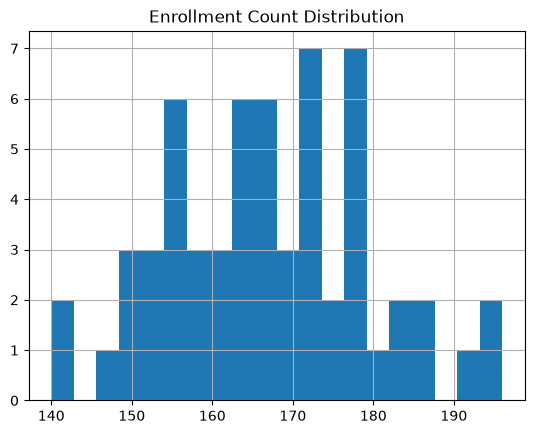

In [118]:
import matplotlib.pyplot as plt

course_data['EnrollmentCount'].hist(bins=20)
plt.title("Enrollment Count Distribution")
plt.show()


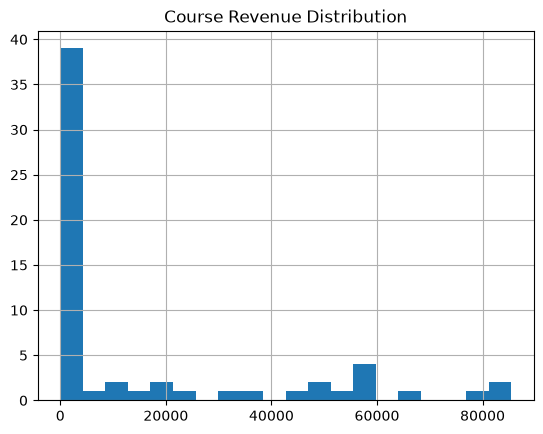

In [119]:
course_data['CourseRevenue'].hist(bins=20)
plt.title("Course Revenue Distribution")
plt.show()

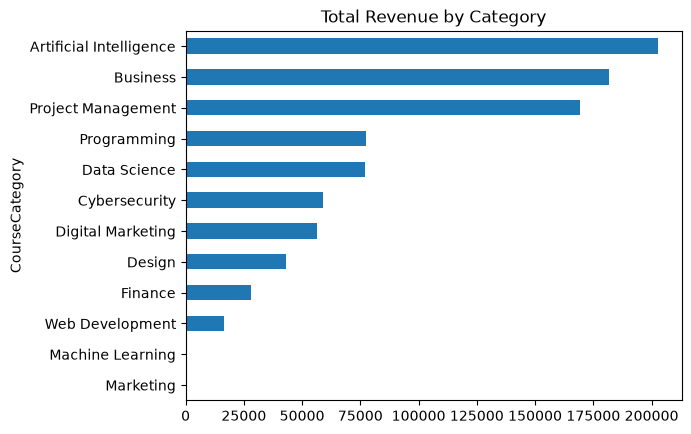

In [120]:
course_data.groupby('CourseCategory')['CourseRevenue'].sum().sort_values().plot(kind='barh')
plt.title("Total Revenue by Category")
plt.show()

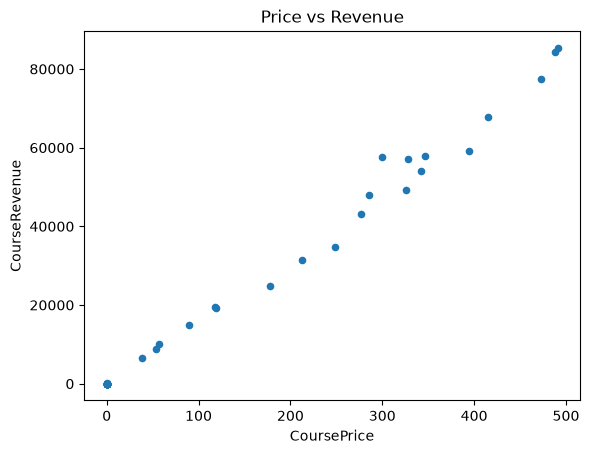

In [121]:
course_data.plot.scatter(x='CoursePrice', y='CourseRevenue')
plt.title("Price vs Revenue")
plt.show()

In [122]:
course_data.corr(numeric_only=True)

,CoursePrice,CourseDuration,CourseRating,EnrollmentCount,CourseRevenue,AvgTeacherRating,AvgTeacherExperience,NumUniqueTeachers
CoursePrice,1.000000,-0.096051,-0.031973,-0.163356,0.996722,-0.094174,0.258599,-0.236518
CourseDuration,-0.096051,1.000000,0.209411,-0.103414,-0.094198,-0.020527,-0.145062,0.162117
CourseRating,-0.031973,0.209411,1.000000,0.294010,-0.018298,-0.013037,-0.069666,0.029430
EnrollmentCount,-0.163356,-0.103414,0.294010,1.000000,-0.116611,0.018949,0.073369,-0.203649
CourseRevenue,0.996722,-0.094198,-0.018298,-0.116611,1.000000,-0.094761,0.253583,-0.235510
AvgTeacherRating,-0.094174,-0.020527,-0.013037,0.018949,-0.094761,1.000000,0.090688,0.115865
AvgTeacherExperience,0.258599,-0.145062,-0.069666,0.073369,0.253583,0.090688,1.000000,-0.204553
NumUniqueTeachers,-0.236518,0.162117,0.029430,-0.203649,-0.235510,0.115865,-0.204553,1.000000


In [123]:
course_data[course_data['CourseCategory'].isin(['Machine Learning','Marketing'])][['CourseName','CourseType','CoursePrice','CourseRevenue']]

,CourseName,CourseType,CoursePrice,CourseRevenue
15,Digital Marketing,Free,0.00,0.00
16,SEO Mastery,Free,0.00,0.00
17,Social Media Marketing,Free,0.00,0.00
18,Content Marketing,Free,0.00,0.00
19,Email Marketing,Free,0.00,0.00
25,Intro to Machine Learning,Free,0.00,0.00
26,Neural Networks,Free,0.00,0.00
27,Deep Learning,Paid,0.78,133.38
28,Natural Language Processing,Free,0.00,0.00
29,Reinforcement Learning,Free,0.00,0.00


In [124]:
def price_band(price):
    if price == 0:
        return 'Free'
    elif price <= 250:
        return 'Low'
    elif price <= 400:
        return 'Medium'
    else:
        return 'High'

course_data['PriceBand'] = course_data['CoursePrice'].apply(price_band)
course_data['PriceBand'].value_counts()

PriceBand
Free      38
Low       10
Medium     8
High       4
Name: count, dtype: int64

In [125]:
course_data['DurationBucket'] = pd.qcut(course_data['CourseDuration'], q=3, labels=['Short','Medium','Long'])
course_data['RatingTier'] = pd.cut(course_data['CourseRating'], bins=[0,3,4,5], labels=['Low','Medium','High'])

level_map = {'Beginner':0, 'Intermediate':1, 'Advanced':2}
course_data['CourseLevelEncoded'] = course_data['CourseLevel'].map(level_map)

course_data[['CoursePrice','PriceBand','CourseDuration','DurationBucket','CourseRating','RatingTier','CourseLevel','CourseLevelEncoded']].head(10)

,CoursePrice,PriceBand,CourseDuration,DurationBucket,CourseRating,RatingTier,CourseLevel,CourseLevelEncoded
0,472.28,High,11.00,Short,4.74,High,Beginner,0
1,0.00,Free,37.70,Medium,2.43,Low,Intermediate,1
2,0.00,Free,19.53,Medium,3.85,Medium,Beginner,0
3,0.00,Free,45.13,Long,2.88,Low,Beginner,0
4,0.00,Free,28.68,Medium,1.28,Low,Beginner,0
5,276.37,Medium,48.84,Long,2.72,Low,Advanced,2
6,0.00,Free,48.68,Long,2.61,Low,Advanced,2
7,0.00,Free,2.87,Short,1.52,Low,Advanced,2
8,0.00,Free,48.19,Long,4.51,High,Beginner,0
9,0.00,Free,15.29,Short,4.45,High,Advanced,2


In [126]:
course_data['RevenuePerEnrollment'] = course_data['CourseRevenue'] / course_data['EnrollmentCount']
import numpy as np
course_data['LogCourseRevenue'] = np.log1p(course_data['CourseRevenue'])
course_data[['CourseRevenue','LogCourseRevenue','RevenuePerEnrollment']].head(10)

,CourseRevenue,LogCourseRevenue,RevenuePerEnrollment
0,77453.92,11.257451,472.28
1,0.00,0.000000,0.00
2,0.00,0.000000,0.00
3,0.00,0.000000,0.00
4,0.00,0.000000,0.00
5,43113.72,10.671620,276.37
6,0.00,0.000000,0.00
7,0.00,0.000000,0.00
8,0.00,0.000000,0.00
9,0.00,0.000000,0.00


In [127]:
course_data['CourseCategory'].unique()

array(['Programming', 'Design', 'Business', 'Marketing', 'Data Science',
       'Machine Learning', 'Cybersecurity', 'Project Management',
       'Finance', 'Artificial Intelligence', 'Web Development',
       'Digital Marketing'], dtype=object)

In [128]:
teachers['Expertise'].unique()

array(['Cybersecurity', 'Digital Marketing', 'Design', 'Machine Learning',
       'Finance', 'Data Science', 'Project Management',
       'Artificial Intelligence', 'Web Development', 'Business',
       'Marketing', 'Programming'], dtype=object)

In [129]:
trans_with_teacher = trans_with_teacher.merge(
    courses[['CourseID', 'CourseCategory']], on='CourseID', how='left')
trans_with_teacher['ExpertiseMatch'] = (
    trans_with_teacher['Expertise'] == trans_with_teacher['CourseCategory']).astype(int)
trans_with_teacher[['CourseID','CourseCategory','Expertise','ExpertiseMatch']].head(10)

,CourseID,CourseCategory,Expertise,ExpertiseMatch
0,CR00016,Marketing,Cybersecurity,0
1,CR00037,Project Management,Cybersecurity,0
2,CR00019,Marketing,Cybersecurity,0
3,CR00048,Artificial Intelligence,Cybersecurity,0
4,CR00060,Digital Marketing,Machine Learning,0
5,CR00042,Finance,Machine Learning,0
6,CR00017,Marketing,Machine Learning,0
7,CR00025,Data Science,Cybersecurity,0
8,CR00003,Programming,Cybersecurity,0
9,CR00032,Cybersecurity,Cybersecurity,1


In [130]:
match_agg = trans_with_teacher.groupby('CourseID')['ExpertiseMatch'].mean().reset_index()
match_agg.columns = ['CourseID', 'ExpertiseMatchScore']
course_data = course_data.merge(match_agg, on='CourseID', how='left')
course_data[['CourseID','CourseCategory','ExpertiseMatchScore']].head(10)

,CourseID,CourseCategory,ExpertiseMatchScore
0,CR00001,Programming,0.134146
1,CR00002,Programming,0.161074
2,CR00003,Programming,0.138728
3,CR00004,Programming,0.162338
4,CR00005,Programming,0.150602
5,CR00006,Design,0.301282
6,CR00007,Design,0.342697
7,CR00008,Design,0.329114
8,CR00009,Design,0.354839
9,CR00010,Design,0.322222


In [131]:
course_data.columns.tolist()

['CourseID',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'CoursePrice',
 'CourseDuration',
 'CourseRating',
 'EnrollmentCount',
 'CourseRevenue',
 'AvgTeacherRating',
 'AvgTeacherExperience',
 'NumUniqueTeachers',
 'PriceBand',
 'DurationBucket',
 'RatingTier',
 'CourseLevelEncoded',
 'RevenuePerEnrollment',
 'LogCourseRevenue',
 'ExpertiseMatchScore']

In [132]:
course_data_encoded = pd.get_dummies(
    course_data,
    columns=['CourseCategory', 'CourseType', 'PriceBand', 'DurationBucket', 'RatingTier'],
    drop_first=True)
course_data_encoded.shape

(60, 34)

In [133]:
corr_matrix = course_data_encoded.corr(numeric_only=True)
high_corr = corr_matrix[(corr_matrix.abs() > 0.85) & (corr_matrix.abs() < 1.0)]
high_corr.dropna(how='all').dropna(axis=1, how='all')

,CoursePrice,CourseRevenue,RevenuePerEnrollment,LogCourseRevenue,CourseType_Paid
CoursePrice,NaN,0.996722,NaN,0.869564,NaN
CourseRevenue,0.996722,NaN,0.996722,0.860008,NaN
RevenuePerEnrollment,NaN,0.996722,NaN,0.869564,NaN
LogCourseRevenue,0.869564,0.860008,0.869564,NaN,0.98605
CourseType_Paid,NaN,NaN,NaN,0.986050,NaN


In [134]:
drop_cols = ['CourseID', 'CourseName', 'CourseLevel', 'CourseRevenue', 'LogCourseRevenue', 
             'EnrollmentCount', 'RevenuePerEnrollment']

X = course_data_encoded.drop(columns=drop_cols)
y_enrollment = course_data_encoded['EnrollmentCount']
y_revenue = course_data_encoded['LogCourseRevenue']

X.shape, y_enrollment.shape, y_revenue.shape

((60, 27), (60,), (60,))

In [135]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y_enrollment, test_size=0.2, random_state=42)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 48
Testing rows: 12


In [136]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Linear Regression")
print("MAE:", mae)
print("R2:", r2)

Linear Regression
MAE: 13.518063197596467
R2: -0.743205597216887


In [137]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
predictions_rf = model_rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, predictions_rf)
r2_rf = r2_score(y_test, predictions_rf)
print("Random Forest")
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
MAE: 12.38583333333333
R2: -0.3789631249999996


In [138]:
from sklearn.model_selection import cross_val_score
model = LinearRegression()
scores = cross_val_score(model, X, y_enrollment, cv=5, scoring='r2')
print("R2 scores across 5 folds:", scores)
print("Average R2:", scores.mean())

R2 scores across 5 folds: [-1.64600752e+01 -2.31656684e+01 -1.51967346e+02 -1.42004695e-01
 -2.80006153e+00]
Average R2: -38.90703124520625


In [139]:
X_train, X_test, y_train, y_test = train_test_split(X, y_revenue, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Linear Regression - Revenue")
print("MAE:", mae)
print("R2:", r2)

Linear Regression - Revenue
MAE: 1.0466656002653518
R2: 0.9315054687795495


In [140]:
from sklearn.linear_model import Ridge
model_ridge = Ridge(alpha=10.0)
scores_ridge = cross_val_score(model_ridge, X, y_enrollment, cv=5, scoring='r2')
print("Ridge R2 scores:", scores_ridge)
print("Average R2:", scores_ridge.mean())

Ridge R2 scores: [-0.16998835  0.09501967  0.09108298  0.01496287 -0.00068613]
Average R2: 0.006078207594070628


In [141]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
scores_rf = cross_val_score(model_rf, X, y_enrollment, cv=5, scoring='r2')
print("Random Forest R2 scores:", scores_rf)
print("Average R2:", scores_rf.mean())

Random Forest R2 scores: [-0.15028768 -0.33168929  0.20805513 -0.19634645 -0.09290152]
Average R2: -0.11263396091828501


In [142]:
model_rf_full = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
model_rf_full.fit(X, y_enrollment)

importances = pd.Series(model_rf_full.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

CourseRating                        0.257737
CourseDuration                      0.247405
CourseCategory_Data Science         0.133775
NumUniqueTeachers                   0.092315
CoursePrice                         0.046679
AvgTeacherExperience                0.044078
ExpertiseMatchScore                 0.041061
AvgTeacherRating                    0.030383
CourseCategory_Digital Marketing    0.029840
CourseLevelEncoded                  0.024482
dtype: float64

In [143]:
model_rf_revenue = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
model_rf_revenue.fit(X, y_revenue)

importances_rev = pd.Series(model_rf_revenue.feature_importances_, index=X.columns)
importances_rev.sort_values(ascending=False).head(10)

CoursePrice                       0.835385
CourseType_Paid                   0.153493
AvgTeacherExperience              0.005813
PriceBand_Low                     0.004673
ExpertiseMatchScore               0.000246
CourseCategory_Web Development    0.000097
PriceBand_High                    0.000067
CourseDuration                    0.000044
NumUniqueTeachers                 0.000037
CourseRating                      0.000036
dtype: float64

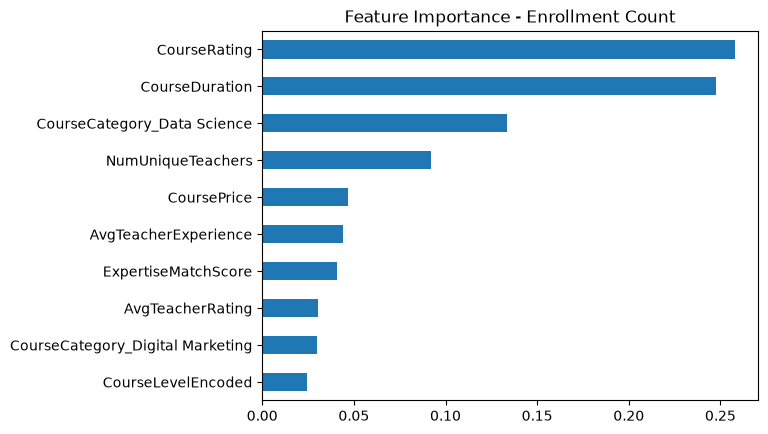

In [144]:
importances.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Feature Importance - Enrollment Count")
plt.gca().invert_yaxis()
plt.show()

In [145]:
import joblib
joblib.dump(model_rf_full, "model_enrollment.pkl")
joblib.dump(model_rf_revenue, "model_revenue.pkl")
print("Models saved!")

Models saved!


In [146]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'analysis.ipynb', 'app.py', 'category_revenue.csv', 'course_data.csv', 'EduPro Online Platform (1).xlsx', 'model_enrollment.pkl', 'model_revenue.pkl']


In [147]:
course_data.columns.tolist()

['CourseID',
 'CourseName',
 'CourseCategory',
 'CourseType',
 'CourseLevel',
 'CoursePrice',
 'CourseDuration',
 'CourseRating',
 'EnrollmentCount',
 'CourseRevenue',
 'AvgTeacherRating',
 'AvgTeacherExperience',
 'NumUniqueTeachers',
 'PriceBand',
 'DurationBucket',
 'RatingTier',
 'CourseLevelEncoded',
 'RevenuePerEnrollment',
 'LogCourseRevenue',
 'ExpertiseMatchScore']

In [148]:
course_data.to_csv("course_data.csv", index=False)
print("Saved!")

Saved!


In [149]:
course_data[course_data['CourseType']=='Free']['CourseRevenue'].describe()

count    38.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: CourseRevenue, dtype: float64

In [89]:
import os
print(os.getcwd())

C:\Users\anjan\ANJANA
